In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [24]:
train_transform = transforms.Compose([
    transforms.Resize((128,128)),       # 统一缩放图片大小
    transforms.RandomHorizontalFlip(),  # 随机水平翻转，数据增强
    transforms.ToTensor(),              # 转为Tensor，像素0~255→[0,1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet标准化
])

In [25]:
val_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [26]:
train_dataset = datasets.ImageFolder(r"D:\ai_env\data\cats_and_dogs\catsdogs\train", transform=train_transform)
val_dataset   = datasets.ImageFolder(r"D:\ai_env\data\cats_and_dogs\catsdogs\val", transform=val_transform)

In [27]:
print(train_dataset.class_to_idx)

{'cat': 0, 'dog': 1}


In [28]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

In [51]:
import torch
from PIL import Image

# 关键：推理用的网络必须和训练时完全一致（同结构、同 forward 拼写）
class CatDogCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128), nn.ReLU(),
            nn.Linear(128, 1),
        )
    def forward(self, x):                 
        return self.fc(self.cnn(x))

model = CatDogCNN().to(device)


In [52]:
criterion = nn.BCEWithLogitsLoss() # 二分类首选，自带sigmoid
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [61]:
epochs = 5
best_val_loss = float("inf")
train_loss_list = []
val_loss_list = []
val_acc_list = []

for epoch in range(epochs):
    # --------训练阶段--------
    model.train()
    total_train_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
        optimizer.zero_grad()
        pred = model(imgs)
        loss = criterion(pred, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    train_loss = total_train_loss / len(train_loader)

    # --------验证阶段--------
    model.eval()
    total_val_loss = 0
    correct = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
            pred = model(imgs)
            loss = criterion(pred, labels)
            total_val_loss += loss.item()
            pred_sigmoid = torch.sigmoid(pred)
            correct += ((pred_sigmoid>0.5) == labels).sum().item()

    val_loss = total_val_loss / len(val_loader)
    val_acc = correct / len(val_loader.dataset)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    print(f'Epoch {epoch+1}/{epochs}, train_loss:{train_loss:.4f}, val_loss:{val_loss:.4f}, acc:{val_acc:.4f}')
    
    # 自动保存val_loss最小的模型
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "catdog_best.pth")
        print(f"✅ 更新最优模型，epoch={epoch+1}")


Epoch 1/5, train_loss:0.0395, val_loss:0.6236, acc:0.8523
✅ 更新最优模型，epoch=1
Epoch 2/5, train_loss:0.0446, val_loss:0.7371, acc:0.8483
Epoch 3/5, train_loss:0.0316, val_loss:0.7597, acc:0.8567
Epoch 4/5, train_loss:0.0324, val_loss:0.8514, acc:0.8395
Epoch 5/5, train_loss:0.0309, val_loss:0.8144, acc:0.8523


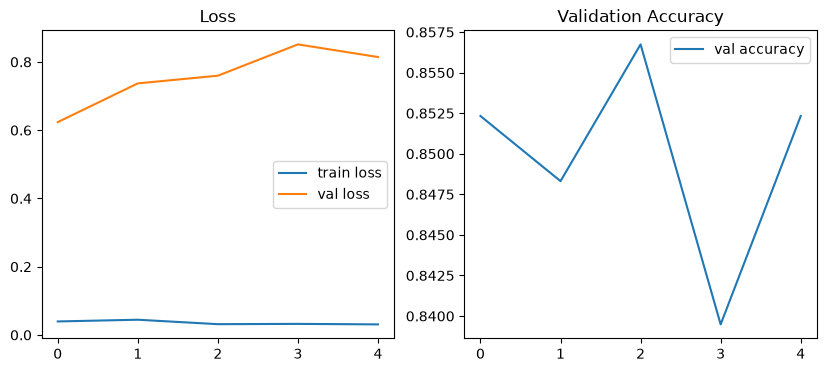

In [62]:
# 保存模型
torch.save(model.state_dict(), "cat_dog_model.pth")
# ========== 7. 绘图查看损失&精度 ==========
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_loss_list, label="train loss")
plt.plot(val_loss_list, label="val loss")
plt.legend()
plt.title("Loss")
plt.subplot(1,2,2)
plt.plot(val_acc_list, label="val accuracy")
plt.legend()
plt.title("Validation Accuracy")
plt.show()